In [14]:

import os
import math
import copy
import time
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [15]:
DATA_PATH = "WineQT.csv"  
TEST_SIZE = 0.15
VAL_SIZE = 0.15
RANDOM_STATE = 42

CUSTOM_EPOCHS = 150
PYTORCH_EPOCHS = 150
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
HIDDEN_SIZES = [64, 32]   # приклад архітектури
ACTIVATIONS = ['relu', 'relu']  # для прихованих шарів
SEED = 42

In [16]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [17]:
def load_and_preprocess_data(csv_path: str, test_size=0.15, val_size=0.15, random_state=42):
    """
    Зчитує CSV, відділяє X/y, нормалізує, розбиває на train/val/test.
    Повертає numpy масиви: X_train, X_val, X_test, y_train, y_val, y_test
    y як цілі класи 0..C-1
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}. Завантажте dataset і вкажіть правильний шлях.")

    df = pd.read_csv(csv_path, sep=';') if ';' in open(csv_path, 'r', encoding='utf-8').readline() else pd.read_csv(csv_path)
    if 'quality' not in df.columns:
        raise ValueError("CSV must contain 'quality' column (target).")

    X = df.drop(columns=['quality']).values.astype(np.float32)
    y_raw = df['quality'].values  # quality (e.g., 3..8)

    # map quality values to contiguous classes 0..K-1
    unique_vals = np.sort(np.unique(y_raw))
    mapping = {v: i for i, v in enumerate(unique_vals)}
    y = np.array([mapping[v] for v in y_raw], dtype=np.int64)
    num_classes = len(unique_vals)
    print(f"Loaded {len(X)} samples, {X.shape[1]} features, {num_classes} classes (qualities: {unique_vals}).")

    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # First split off test, then split remaining into train/val
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    # val_size is proportion of full data -> convert to proportion of temp
    val_prop_of_temp = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_prop_of_temp, random_state=random_state, stratify=y_temp)

    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    return X_train, X_val, X_test, y_train, y_val, y_test, num_classes, scaler, mapping


In [18]:
class Activations:
    @staticmethod
    def relu(Z, derivative=False):
        if derivative:
            return (Z > 0).astype(np.float32)
        return np.maximum(0.0, Z)

    @staticmethod
    def tanh(Z, derivative=False):
        if derivative:
            return 1.0 - np.tanh(Z) ** 2
        return np.tanh(Z)

    @staticmethod
    def softmax(Z):
        # Z shape: (n_out, m)
        Z_max = np.max(Z, axis=0, keepdims=True)
        exp = np.exp(Z - Z_max)
        return exp / np.sum(exp, axis=0, keepdims=True)

In [19]:
class Losses:
    @staticmethod
    def categorical_cross_entropy(probs: np.ndarray, y_true: np.ndarray): 
        """
        probs: (K, m) probabilities
        y_true: (m,) integer labels
        returns average loss
        """
        m = y_true.shape[0]
        # avoid log(0)
        p = probs[y_true, np.arange(m)]
        loss = -np.mean(np.log(p + 1e-12))
        return loss

    @staticmethod
    def d_softmax_crossentropy(probs: np.ndarray, y_true: np.ndarray):
        """
        Optimized derivative for softmax + cross-entropy.
        probs: (K, m), y_true: (m,)
        Returns dZ shape (K, m) - gradient of loss wrt logits Z
        """
        m = y_true.shape[0]
        grad = probs.copy()
        grad[y_true, np.arange(m)] -= 1.0
        grad /= m
        return grad


In [20]:
class CustomMLP:
    def __init__(self, input_size: int, hidden_sizes: List[int], output_size: int,
                 activations: List[str], learning_rate: float = 1e-3, seed: int = 42):
        """
        We use numpy arrays for all params. Shapes:
          W1: (hidden1, input_size)
          b1: (hidden1, 1)
          ...
          WL: (output_size, hidden_last)
          bL: (output_size, 1)
        activations: list for hidden layers. output -> softmax
        """
        np.random.seed(seed)
        self.layer_sizes = [input_size] + hidden_sizes + [output_size]
        self.num_layers = len(self.layer_sizes) - 1
        assert len(activations) == self.num_layers - 1, "activations length must match hidden layers"
        self.activations = activations
        self.lr = learning_rate
        self.parameters: Dict[str, np.ndarray] = {}
        self._init_params_xavier()

    def _init_params_xavier(self):
        for i in range(1, len(self.layer_sizes)):
            n_out = self.layer_sizes[i]
            n_in = self.layer_sizes[i - 1]
            # Xavier / Glorot
            limit = math.sqrt(6.0 / (n_in + n_out))
            W = np.random.uniform(-limit, limit, size=(n_out, n_in)).astype(np.float32)
            b = np.zeros((n_out, 1), dtype=np.float32)
            self.parameters[f"W{i}"] = W
            self.parameters[f"b{i}"] = b

    def forward(self, X: np.ndarray, training: bool = True) -> Tuple[np.ndarray, Dict]:
        """
        X: (m, input_size) -> we convert to (input_size, m) internally
        Returns probabilities (K, m) and cache
        cache holds Z and A for each layer in column-major (A0..AL)
        """
        A = X.T  # (input_size, m)
        cache: Dict[str, np.ndarray] = {}
        cache['A0'] = A
        for i in range(1, self.num_layers + 1):
            W = self.parameters[f"W{i}"]
            b = self.parameters[f"b{i}"]
            Z = W @ A + b  # shapes: (n_out, m)
            cache[f"Z{i}"] = Z
            if i == self.num_layers:
                # output layer -> softmax
                A = Activations.softmax(Z)
            else:
                act = self.activations[i - 1].lower()
                if act == 'relu':
                    A = Activations.relu(Z)
                elif act == 'tanh':
                    A = Activations.tanh(Z)
                else:
                    raise ValueError(f"Unknown activation: {act}")
            cache[f"A{i}"] = A
        return A, cache

    def backward_and_update(self, cache: Dict, X_batch: np.ndarray, y_batch: np.ndarray):
        """
        Perform backward pass and update parameters in-place using SGD.
        X_batch: (m, input_size)
        y_batch: (m,)
        """
        m = X_batch.shape[0]
        # get probs and compute dZ at output
        probs = cache[f"A{self.num_layers}"]  # (K, m)
        dZ = Losses.d_softmax_crossentropy(probs, y_batch)  # (K, m)
        for i in reversed(range(1, self.num_layers + 1)):
            A_prev = cache[f"A{i-1}"]  # (n_prev, m)
            # gradients
            dW = dZ @ A_prev.T  # (n_out, n_prev)
            db = np.sum(dZ, axis=1, keepdims=True)  # (n_out, 1)
            # update parameters (SGD)
            self.parameters[f"W{i}"] -= self.lr * dW
            self.parameters[f"b{i}"] -= self.lr * db
            # prepare dZ for previous layer if any
            if i > 1:
                W = self.parameters[f"W{i}"]
                dA_prev = W.T @ dZ  # (n_prev, m)
                Z_prev = cache[f"Z{i-1}"]
                act = self.activations[i - 2].lower()
                if act == 'relu':
                    dZ = dA_prev * Activations.relu(Z_prev, derivative=True)
                elif act == 'tanh':
                    dZ = dA_prev * Activations.tanh(Z_prev, derivative=True)
                else:
                    raise ValueError(f"Unknown activation: {act}")

    def predict(self, X: np.ndarray) -> np.ndarray:
        probs, _ = self.forward(X, training=False)
        preds = np.argmax(probs, axis=0)
        return preds

    def fit(self, X_train: np.ndarray, y_train: np.ndarray,
            X_val: np.ndarray, y_val: np.ndarray,
            epochs: int = 100, batch_size: int = 64, verbose: bool = True):
        n = X_train.shape[0]
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        for epoch in range(1, epochs + 1):
            permutation = np.random.permutation(n)
            X_shuffled = X_train[permutation]
            y_shuffled = y_train[permutation]

            epoch_losses = []
            for i in range(0, n, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
                probs, cache = self.forward(X_batch, training=True)
                loss = Losses.categorical_cross_entropy(probs, y_batch)
                epoch_losses.append(loss)
                self.backward_and_update(cache, X_batch, y_batch)

            train_loss = float(np.mean(epoch_losses))
            y_pred_train = self.predict(X_train)
            y_pred_val = self.predict(X_val)
            train_acc = float(accuracy_score(y_train, y_pred_train))
            val_acc = float(accuracy_score(y_val, y_pred_val))

            val_probs, _ = self.forward(X_val, training=False)
            val_loss = float(Losses.categorical_cross_entropy(val_probs, y_val))

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)

            if verbose and (epoch % max(1, epochs // 10) == 0 or epoch == 1 or epoch == epochs):
                print(f"[Custom] Epoch {epoch}/{epochs}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")
        return history


In [21]:
class PyTorchMLP(nn.Module):
    def __init__(self, input_size: int, hidden_sizes: List[int], output_size: int, activations: List[str]):
        super().__init__()
        layers = []
        in_size = input_size
        for i, h in enumerate(hidden_sizes):
            layers.append(nn.Linear(in_size, h))
            act = activations[i].lower()
            if act == 'relu':
                layers.append(nn.ReLU())
            elif act == 'tanh':
                layers.append(nn.Tanh())
            else:
                raise ValueError(f"Unknown activation: {act}")
            in_size = h
        layers.append(nn.Linear(in_size, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [22]:
def train_pytorch_model(model: nn.Module, X_train: np.ndarray, y_train: np.ndarray,
                        X_val: np.ndarray, y_val: np.ndarray,
                        epochs=100, batch_size=64, lr=1e-3, device='cpu', verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_tensor = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(y_train.astype(np.int64)))
    val_tensor = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(y_val.astype(np.int64)))
    train_loader = DataLoader(train_tensor, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_tensor, batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_losses.append(loss.item())

        train_loss = float(np.mean(running_losses))

        # eval
        model.eval()
        with torch.no_grad():
            # train acc
            Xtr = torch.from_numpy(X_train.astype(np.float32)).to(device)
            ytr = torch.from_numpy(y_train.astype(np.int64)).to(device)
            out_tr = model(Xtr)
            pred_tr = torch.argmax(out_tr, dim=1).cpu().numpy()
            train_acc = float(accuracy_score(y_train, pred_tr))
            # val
            Xv = torch.from_numpy(X_val.astype(np.float32)).to(device)
            yv = torch.from_numpy(y_val.astype(np.int64)).to(device)
            out_v = model(Xv)
            loss_v = criterion(out_v, yv).item()
            pred_v = torch.argmax(out_v, dim=1).cpu().numpy()
            val_acc = float(accuracy_score(y_val, pred_v))
        history['train_loss'].append(train_loss)
        history['val_loss'].append(loss_v)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if verbose and (epoch % max(1, epochs // 10) == 0 or epoch == 1 or epoch == epochs):
            print(f"[PyTorch] Epoch {epoch}/{epochs}: train_loss={train_loss:.4f}, val_loss={loss_v:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

    return model, history

In [23]:

def train_custom_mlp(model, X_train, y_train, X_val, y_val, epochs=1000):
    history = {'train_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        model.forward(X_train)
        loss = LossFunctions.categorical_cross_entropy(model.cache[f'A{len(model.layer_sizes)-1}'].T, y_train)
        model.backward(X_train, y_train)
        
        history['train_loss'].append(loss.item())
        
        if epoch % 100 == 0:
            with torch.no_grad():
                val_preds = model.predict(X_val)
                acc = accuracy_score(y_val.numpy(), val_preds.numpy())
                history['val_acc'].append(acc)
                print(f"Custom MLP | Epoch {epoch}: Train Loss = {loss:.4f}, Val Acc = {acc:.4f}")
    return history

def train_pytorch_mlp(model, X_train, y_train, X_val, y_val, epochs=1000):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    history = {'train_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()


In [24]:
def plot_history(hist_custom: Dict, hist_torch: Dict):
    epochs_c = len(hist_custom['train_loss'])
    epochs_t = len(hist_torch['train_loss'])
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(range(1, epochs_c+1), hist_custom['train_loss'], label='Custom train')
    plt.plot(range(1, epochs_c+1), hist_custom['val_loss'], label='Custom val')
    plt.plot(range(1, epochs_t+1), hist_torch['train_loss'], label='PyTorch train', linestyle='--')
    plt.plot(range(1, epochs_t+1), hist_torch['val_loss'], label='PyTorch val', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss curves')

    plt.subplot(1,2,2)
    plt.plot(range(1, epochs_c+1), hist_custom['train_acc'], label='Custom train')
    plt.plot(range(1, epochs_c+1), hist_custom['val_acc'], label='Custom val')
    plt.plot(range(1, epochs_t+1), hist_torch['train_acc'], label='PyTorch train', linestyle='--')
    plt.plot(range(1, epochs_t+1), hist_torch['val_acc'], label='PyTorch val', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy curves')

    plt.tight_layout()
    plt.show()

In [25]:
X_train, X_val, X_test, y_train, y_val, y_test, num_classes, scaler, mapping = load_and_preprocess_data(DATA_PATH, TEST_SIZE, VAL_SIZE, RANDOM_STATE)
input_size = X_train.shape[1]
print("Input size:", input_size, "Num classes:", num_classes)


Loaded 1143 samples, 12 features, 6 classes (qualities: [3 4 5 6 7 8]).
Train: 799, Val: 172, Test: 172
Input size: 12 Num classes: 6


In [26]:
print("\nInitializing Custom MLP (no autograd)...")
custom = CustomMLP(input_size=input_size, hidden_sizes=HIDDEN_SIZES, output_size=num_classes,
                       activations=ACTIVATIONS, learning_rate=LEARNING_RATE, seed=SEED)

t0 = time.time()
hist_custom = custom.fit(X_train, y_train, X_val, y_val, epochs=CUSTOM_EPOCHS, batch_size=BATCH_SIZE, verbose=True)
t1 = time.time()
print(f"Custom training finished in {t1 - t0:.1f}s")

y_test_pred_custom = custom.predict(X_test)


Initializing Custom MLP (no autograd)...
[Custom] Epoch 1/150: train_loss=1.8573, val_loss=1.8161, train_acc=0.2441, val_acc=0.2733
[Custom] Epoch 15/150: train_loss=1.6943, val_loss=1.6665, train_acc=0.3079, val_acc=0.3314
[Custom] Epoch 30/150: train_loss=1.5629, val_loss=1.5536, train_acc=0.3567, val_acc=0.3837
[Custom] Epoch 45/150: train_loss=1.4696, val_loss=1.4662, train_acc=0.3917, val_acc=0.4302
[Custom] Epoch 60/150: train_loss=1.3855, val_loss=1.3967, train_acc=0.4343, val_acc=0.4128
[Custom] Epoch 75/150: train_loss=1.3261, val_loss=1.3416, train_acc=0.4581, val_acc=0.4244
[Custom] Epoch 90/150: train_loss=1.2804, val_loss=1.2983, train_acc=0.4856, val_acc=0.4651
[Custom] Epoch 105/150: train_loss=1.2427, val_loss=1.2637, train_acc=0.5094, val_acc=0.4593
[Custom] Epoch 120/150: train_loss=1.2153, val_loss=1.2355, train_acc=0.5106, val_acc=0.4709
[Custom] Epoch 135/150: train_loss=1.1789, val_loss=1.2121, train_acc=0.5181, val_acc=0.4884
[Custom] Epoch 150/150: train_loss=1

In [27]:
print("\nInitializing PyTorch MLP...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
pytorch_model = PyTorchMLP(input_size=input_size, hidden_sizes=HIDDEN_SIZES, output_size=num_classes, activations=ACTIVATIONS)

t0 = time.time()
pytorch_model_trained, hist_torch = train_pytorch_model(pytorch_model, X_train, y_train, X_val, y_val,
                                                           epochs=PYTORCH_EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE,
                                                           device=device, verbose=True)
t1 = time.time()
print(f"PyTorch training finished in {t1 - t0:.1f}s on device {device}")


Initializing PyTorch MLP...
[PyTorch] Epoch 1/150: train_loss=1.7504, val_loss=1.6843, train_acc=0.4218, val_acc=0.4360
[PyTorch] Epoch 15/150: train_loss=0.9027, val_loss=1.0408, train_acc=0.6258, val_acc=0.6047
[PyTorch] Epoch 30/150: train_loss=0.8306, val_loss=1.0272, train_acc=0.6546, val_acc=0.5930
[PyTorch] Epoch 45/150: train_loss=0.7547, val_loss=1.0411, train_acc=0.6909, val_acc=0.5814
[PyTorch] Epoch 60/150: train_loss=0.7005, val_loss=1.0601, train_acc=0.7159, val_acc=0.5814
[PyTorch] Epoch 75/150: train_loss=0.6474, val_loss=1.0894, train_acc=0.7472, val_acc=0.5872
[PyTorch] Epoch 90/150: train_loss=0.5914, val_loss=1.1254, train_acc=0.7785, val_acc=0.5988
[PyTorch] Epoch 105/150: train_loss=0.5440, val_loss=1.1769, train_acc=0.8035, val_acc=0.5756
[PyTorch] Epoch 120/150: train_loss=0.4927, val_loss=1.2305, train_acc=0.8248, val_acc=0.5872
[PyTorch] Epoch 135/150: train_loss=0.4598, val_loss=1.3089, train_acc=0.8461, val_acc=0.5233
[PyTorch] Epoch 150/150: train_loss=0.4

In [28]:
pytorch_model_trained.eval()
with torch.no_grad():
        Xtest_t = torch.from_numpy(X_test.astype(np.float32)).to(device)
        out = pytorch_model_trained(Xtest_t)
        y_test_pred_torch = torch.argmax(out, dim=1).cpu().numpy()

acc_custom = accuracy_score(y_test, y_test_pred_custom)
acc_torch = accuracy_score(y_test, y_test_pred_torch)
print(f"\nTest accuracy: Custom MLP = {acc_custom:.4f}, PyTorch = {acc_torch:.4f}")


Test accuracy: Custom MLP = 0.5465, PyTorch = 0.6686


In [30]:
def plot_confusion(y_true, y_pred_custom, y_pred_torch, class_names):
    cm_c = confusion_matrix(y_true, y_pred_custom)
    cm_t = confusion_matrix(y_true, y_pred_torch)
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    sns.heatmap(cm_c, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title('Custom MLP Confusion Matrix')
    axes[0].set_xlabel('Pred'); axes[0].set_ylabel('True')
    sns.heatmap(cm_t, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title('PyTorch MLP Confusion Matrix')
    axes[1].set_xlabel('Pred'); axes[1].set_ylabel('True')
    plt.tight_layout()
    plt.show()

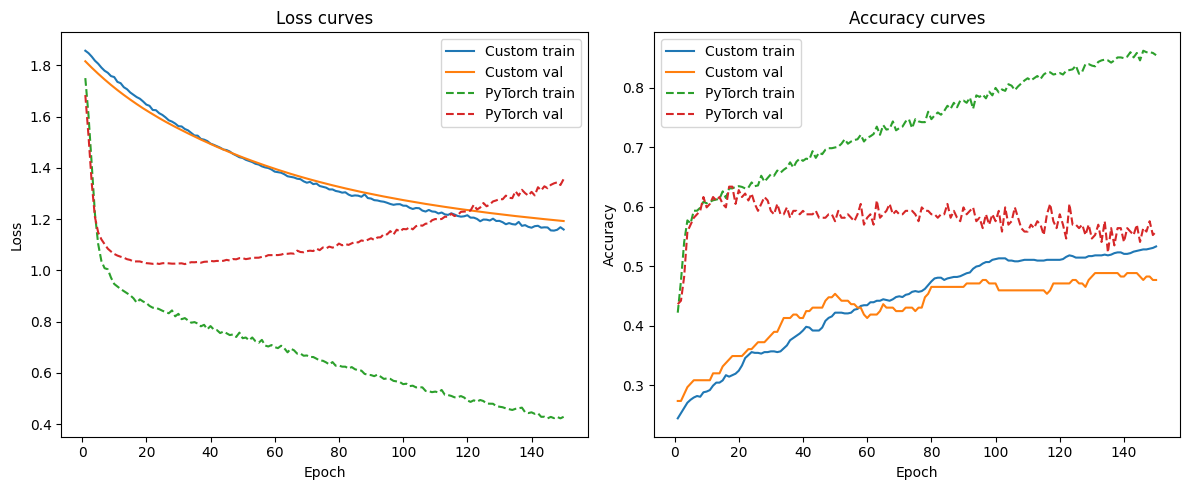

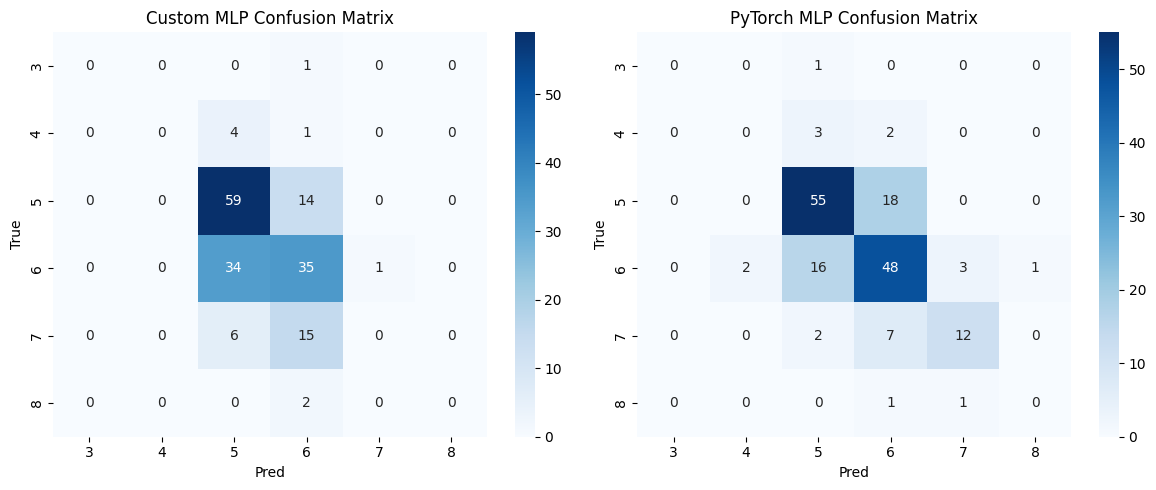

In [31]:

plot_history(hist_custom, hist_torch)

class_names = [str(k) for k in sorted(mapping.keys())]  # original quality labels
plot_confusion(y_test, y_test_pred_custom, y_test_pred_torch, class_names)

    

In [32]:
import pandas as pd
summary = pd.DataFrame({
        'model': ['CustomMLP', 'PyTorchMLP'],
        'test_accuracy': [acc_custom, acc_torch],
        'train_time_sec': [None, None]  # we printed times earlier; optional to fill
    })
print("\nSummary:\n", summary)



Summary:
         model  test_accuracy train_time_sec
0   CustomMLP       0.546512           None
1  PyTorchMLP       0.668605           None
